In [ ]:
# 1. Go to kaggle.com -> Account -> Create New API Token -> download kaggle.json
# 2. Upload kaggle.json to your Google Drive

from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /root/.kaggle
!cp "/content/drive/MyDrive/kaggle.json" /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d moltean/fruits


Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 6.52G/6.52G [00:31<00:00, 222MB/s]



In [ ]:
!pip install -q kaggle

In [ ]:
import tensorflow as tf
import zipfile


with zipfile.ZipFile('fruits.zip','r') as zip_ref:
  zip_ref.extractall('/content')


  train_ds=tf.keras.preprocessing.image_dataset_from_directory("/content/fruits-360_100x100/fruits-360/Training",validation_split=0.2,subset='training',seed=42, image_size=(128,128),batch_size=32)
  val_ds=tf.keras.preprocessing.image_dataset_from_directory("/content/fruits-360_100x100/fruits-360/Test",validation_split=0.2,subset='training',seed=42, image_size=(128,128),batch_size=32)


Found 137221 files belonging to 260 classes.
Using 109777 files for training.
Found 45724 files belonging to 260 classes.
Using 36580 files for training.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, MaxPooling2D

In [ ]:
normalization_layers= tf.keras.layers.Rescaling(1./255)

train_data = train_ds.map(lambda x,y : (normalization_layers(x), y))

val_data = val_ds.map(lambda x, y : (normalization_layers(x), y))

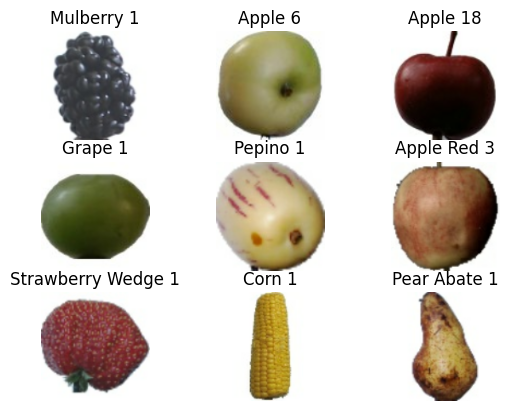

In [ ]:
import matplotlib.pyplot as plt


class_names = train_ds.class_names

for images, labels in train_data.take(1):
  for i in range(9):
    plt.subplot(3,3, i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.show()

In [ ]:
from keras.src.layers import Conv2D
from keras.src.layers.pooling.max_pooling2d import MaxPooling2D
from keras.src.models.sequential import Sequential
model = Sequential()

model.add(Conv2D(32, (3,3), activation = 'relu', input_shape = (128, 128, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3,3), activation = 'relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3,3), activation = 'relu'))
model.add(MaxPooling2D())

model.add(Conv2D(256, (3,3), activation = 'relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(len(class_names), activation = 'softmax'))

In [ ]:
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer= 'adam',
    metrics = ['accuracy']
)

In [ ]:
model.fit(
    train_data,
    validation_data=(val_ds),
    verbose= 1,
    epochs = 10
)

Epoch 1/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 125s 34ms/step - accuracy: 0.7606 - loss: 0.9029 - val_accuracy: 0.2954 - val_loss: 1330.1643
Epoch 2/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 103s 30ms/step - accuracy: 0.9445 - loss: 0.1621 - val_accuracy: 0.2628 - val_loss: 1586.3115
Epoch 3/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 96s 28ms/step - accuracy: 0.9623 - loss: 0.1093 - val_accuracy: 0.3012 - val_loss: 1444.7562
Epoch 4/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 151s 31ms/step - accuracy: 0.9718 - loss: 0.0827 - val_accuracy: 0.2841 - val_loss: 1845.4841
Epoch 5/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 86s 25ms/step - accuracy: 0.9771 - loss: 0.0694 - val_accuracy: 0.3112 - val_loss: 1634.9073
Epoch 6/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 92s 27ms/step - accuracy: 0.9816 - loss: 0.0559 - val_accuracy: 0.3801 - val_loss: 1415.3834
Epoch 7/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 85s 25ms/step - accuracy: 0.9832 - loss: 0.0561 - val_accuracy: 0.3814 - val_loss: 1552.6027
Epoch 8/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 142s 25ms/

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image


img_path = '/content/fruits-360_100x100/fruits-360/Test/Apple 10'
imag = image.load_img(img_path, target_size = (128,128))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis = 0)

predictions = model.predict(img_array)

predicted_class_idx = np.argmax(predictions[0])

predicted_class_name = class_names[predicted_class_idx]

print(f"Predicted Class : {predicted_class_name}")


In [ ]:
model.save("fruits_360.h5")